# Clasificadores Bayesianos

El objetivo es construir paso a paso un clasificador bayesiano para reconocer dígitos manuscritos y, a partir de esa construcción, introducir el clasificador **Naive Bayes Gaussiano**.

La práctica sigue dos ideas centrales: 

- primero se trabaja con **una única característica** para poder visualizar todas las probabilidades involucradas
- luego se incorporan **dos características** para introducir el supuesto de independencia condicional de Naive Bayes.

In [3]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from IPython.display import Image, display
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

figure_dir = './2_imagenes/'
data_dir = './1_datos/'

# 1. Clasificador de Bayes

El clasificador de Bayes aborda la clasificación desde un **modelo probabilístico**. 

Para una muestra $x$, estima la probabilidad de pertenencia a cada clase y toma la decisión utilizando esas probabilidades.

# 2. Conceptos de probabilidad fundamentales para clasificación

Antes de construir el clasificador, revisaremos las cantidades que aparecen en la regla de Bayes.

### Probabilidad a priori $P(w_i)$

Representa la probabilidad de observar la clase $w_i$ **antes de conocer el valor de la muestra**. 

En un conjunto de entrenamiento puede estimarse como la proporción de ejemplos de esa clase.

***Ej. Cuál es la probabilidad de encontrar individuos anémicos en una población de individuos anémicos + sanos***

### Probabilidad condicional $p(x\mid w_i)$ — *likelihood*

Indica qué tan compatible es observar el valor $x$ si sabemos que la muestra pertenece a la clase $w_i$.

Para variables continuas, como la característica que usaremos en esta práctica, trabajaremos con una **función de densidad de probabilidad**.

***Ej. Tengo 2 grupos etiquetados con sanos y anémicos, cuál es la probabilidad de sacar un conteo de glóbulos rojos 2.000.000, conociendo la clase a la que pertenece la muestra.***

### Densidad conjunta $p(x,w_i)$

Probabilidad de observar la muestra $x$ con la etiqueta $w_i$

Combina la evidencia proporcionada por $x$ con la probabilidad a priori de la clase:

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

***Ej. Ahora tengo todas las muestras de los 2 grupos mezcladas, cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 y que sea un individuo sano***

### Densidad marginal $p(x)$

Representa la densidad de observar $x$ sin conocer la clase. Para dos clases:

$$p(x)=p(x,w_0)+p(x,w_1).$$

Para varias clases:

$$
p(x) = \sum\limits_{j=1}^{c}p(x,w_j) = \sum\limits_{j=1}^{c}p(x|w_j)P(w_j) 
$$

***Ej. cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 sin importar la clase***

### Probabilidad a posteriori $P(w_i\mid x)$

Probabilidad de observar una etiqueta $w_i$  conociendo el valor de la muestra $x$

Se obtiene mediante la regla de Bayes:

$$P(w_i\mid x)=\frac{p(x\mid w_i)P(w_i)}{p(x)}=\frac{p(x,w_i)}{p(x)}.$$

## Clasificador Bayesiano

El clasificador asigna $x$ a la clase con mayor probabilidad a posteriori:

$$\hat w=\arg\max_{w_i}P(w_i\mid x).$$

Como $p(x)$ es el mismo para todas las clases al comparar una misma muestra, la decisión también puede escribirse como

$$\hat w_{MAP}=\arg\max_{w_i} p(x\mid w_i)P(w_i).$$

Esta regla se denomina **máxima a posteriori (MAP)**.

# 3. Ejemplo de aplicación: OCR de dígitos manuscritos 0 y 1

Implementar un clasificador de Bayes para el reconocimiento óptico de caracteres (OCR) de los dígitos manuscritos **0 y 1**.

A continuación se muestran ejemplos de las imágenes binarizadas que utilizaremos.

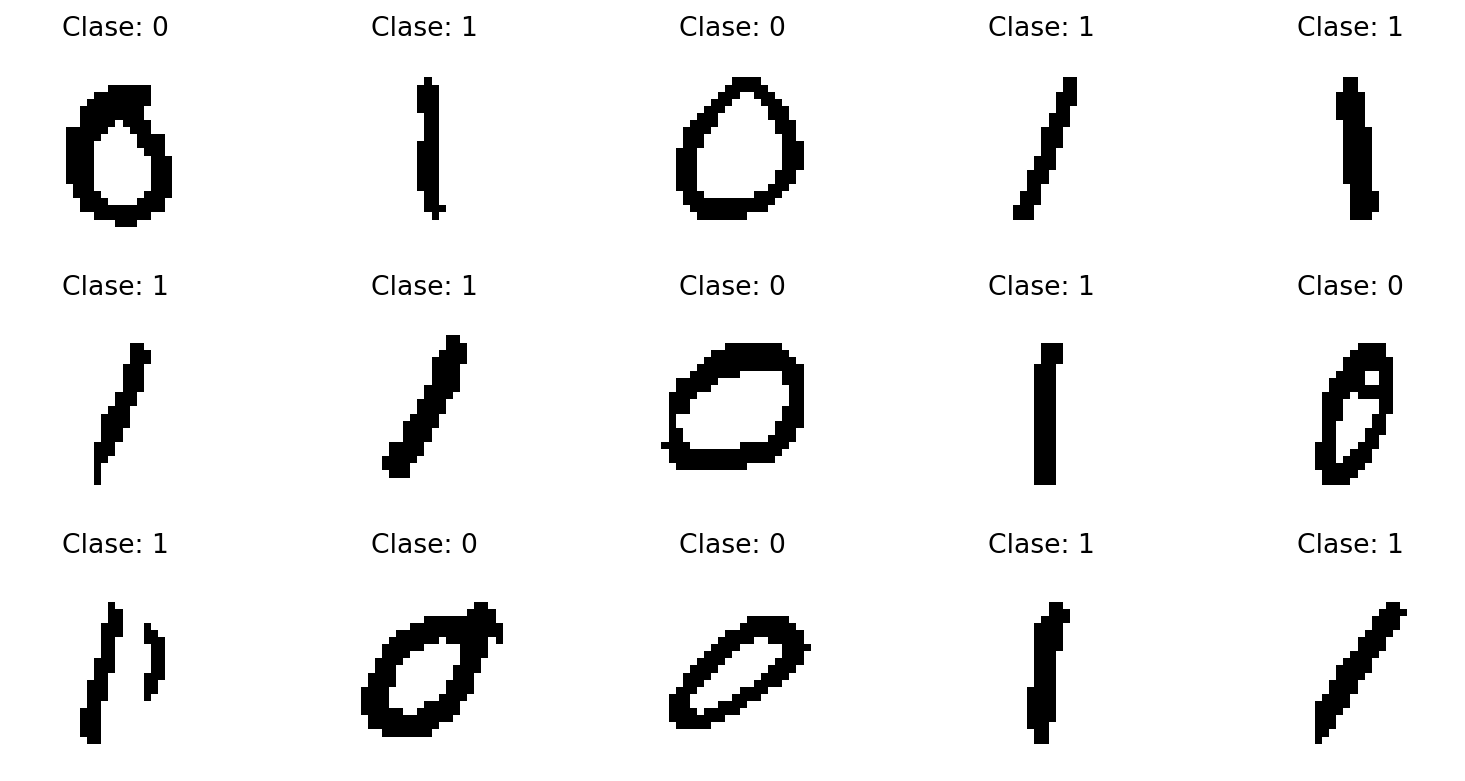

In [6]:
display(Image(filename=str(figure_dir + 'digitos_0_1.png'), width=800))

Cada imagen está almacenada originalmente como un vector de 784 intensidades, correspondiente a una imagen de $28\times 28$ píxeles. Después de aplicar un umbral de 127, cada píxel queda representado por 0 o 1.

Para comenzar con un problema unidimensional, resumiremos cada imagen mediante una única característica que en esta práctica denominaremos **brillo global**:

$$x=\#\{\text{píxeles con valor }0\}.$$

Es decir, se cuenta la cantidad de píxeles de fondo según la convención de binarización utilizada.

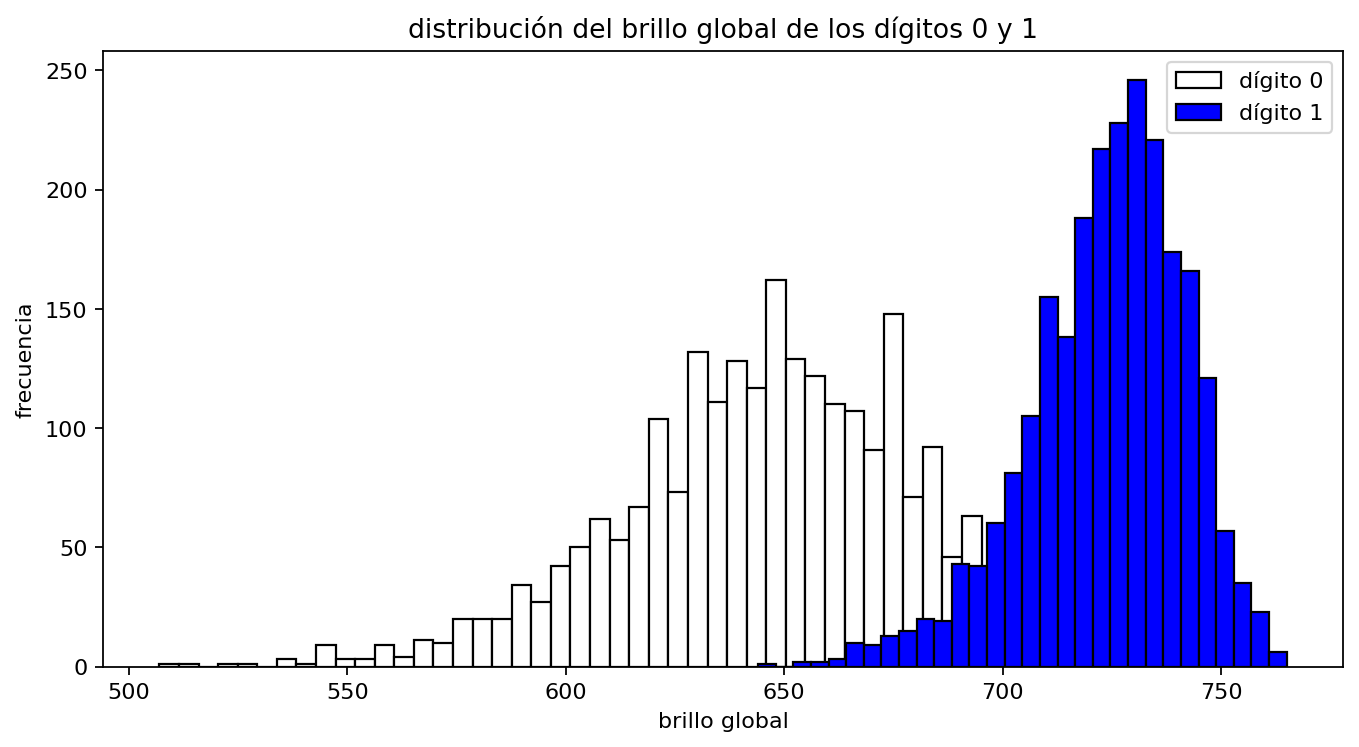

In [7]:
display(Image(filename=str(figure_dir + 'brillo_global_hist.png'), width=800))

Los histogramas muestran que la característica presenta distribuciones diferentes en ambas clases. Como el dataset contiene la misma cantidad de ceros y unos, esperamos probabilidades a priori similares para las dos clases.

Para modelar $p(x\mid w_i)$ aproximaremos la distribución del brillo global de cada clase mediante una distribución normal o gaussiana.

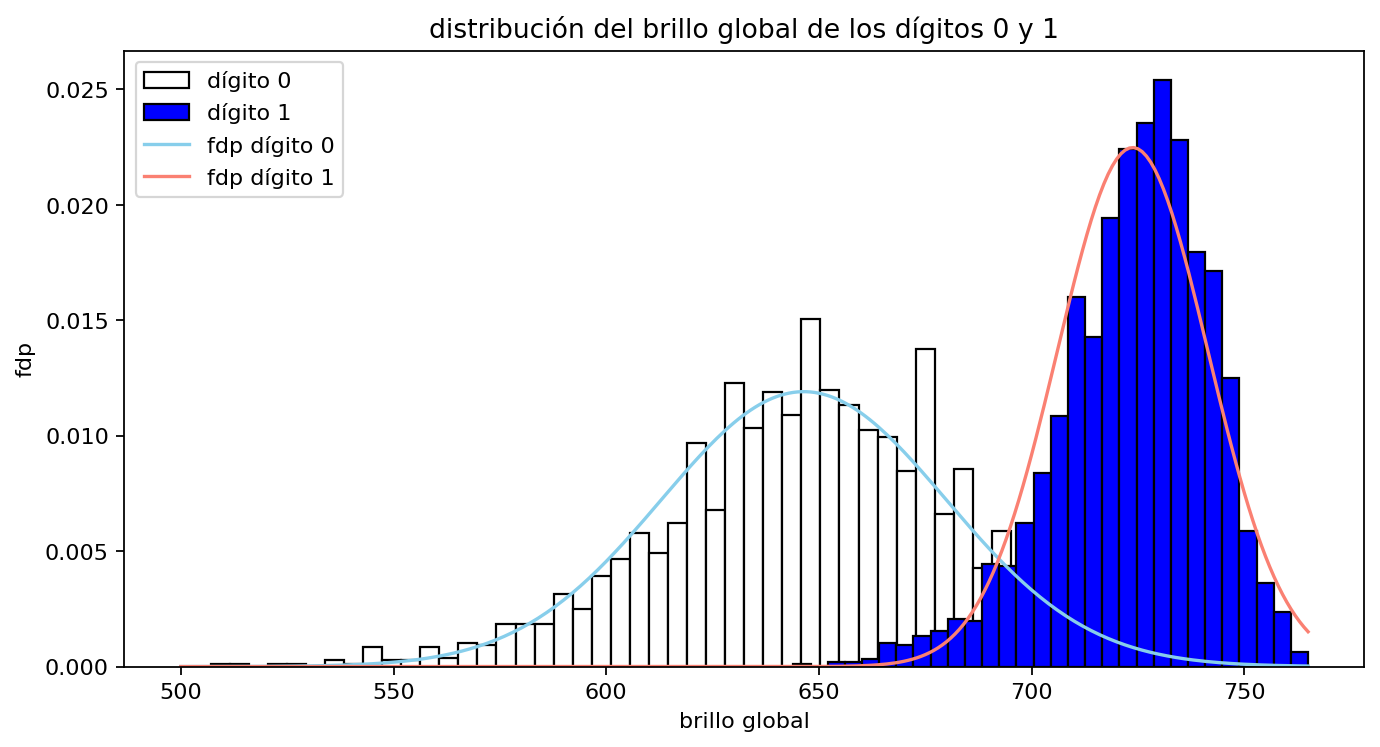

In [8]:
display(Image(filename=str(figure_dir + 'fdp.png'), width=900))

A partir de $p(x\mid w_i)$ y $P(w_i)$ se obtienen las densidades conjuntas $p(x,w_i)$:

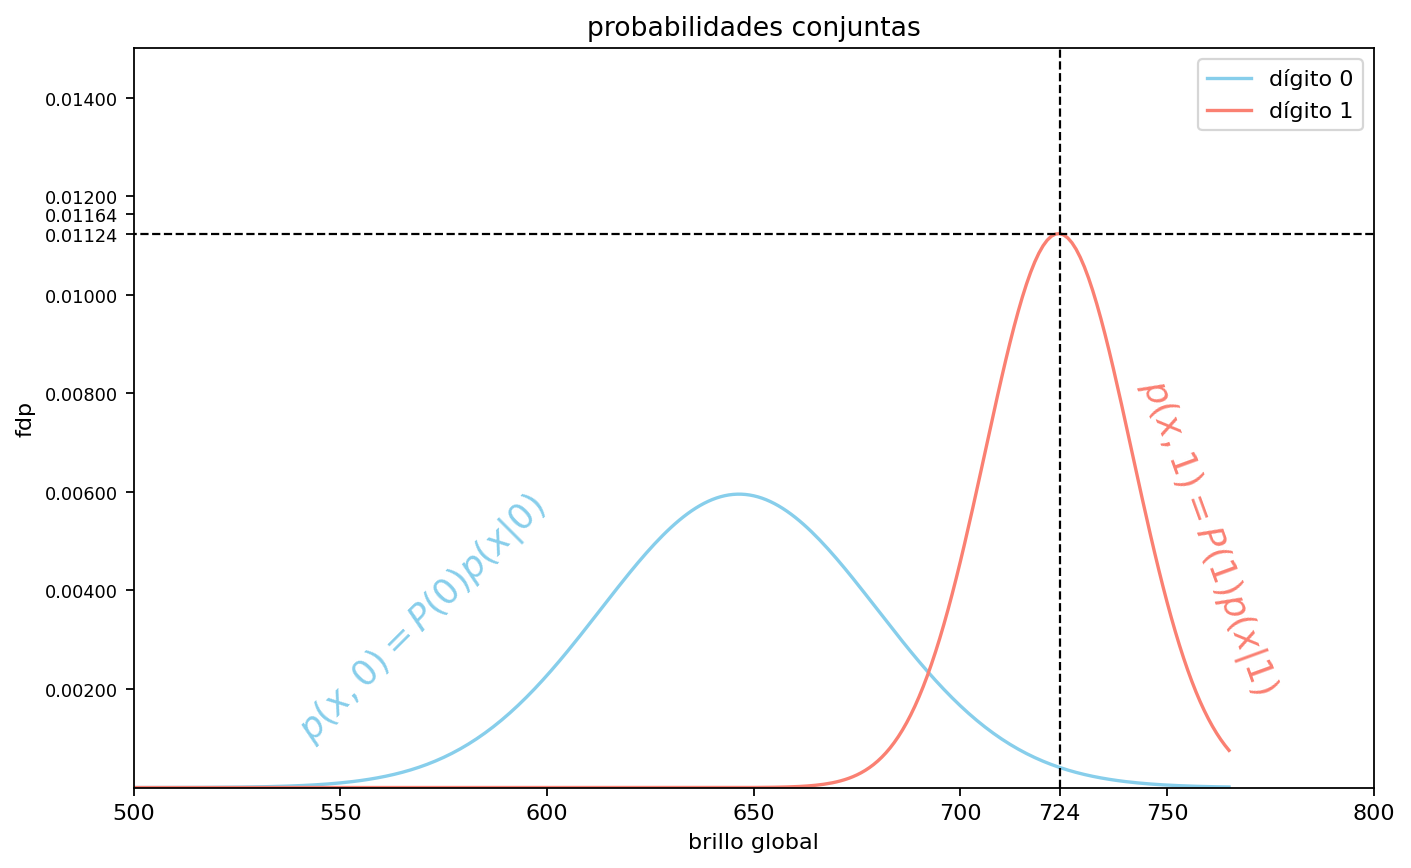

In [9]:
display(Image(filename=str(figure_dir + 'prob_conjunta.png'), width=1000))

Sumando las densidades conjuntas de las clases se obtiene la densidad marginal $p(x)$:

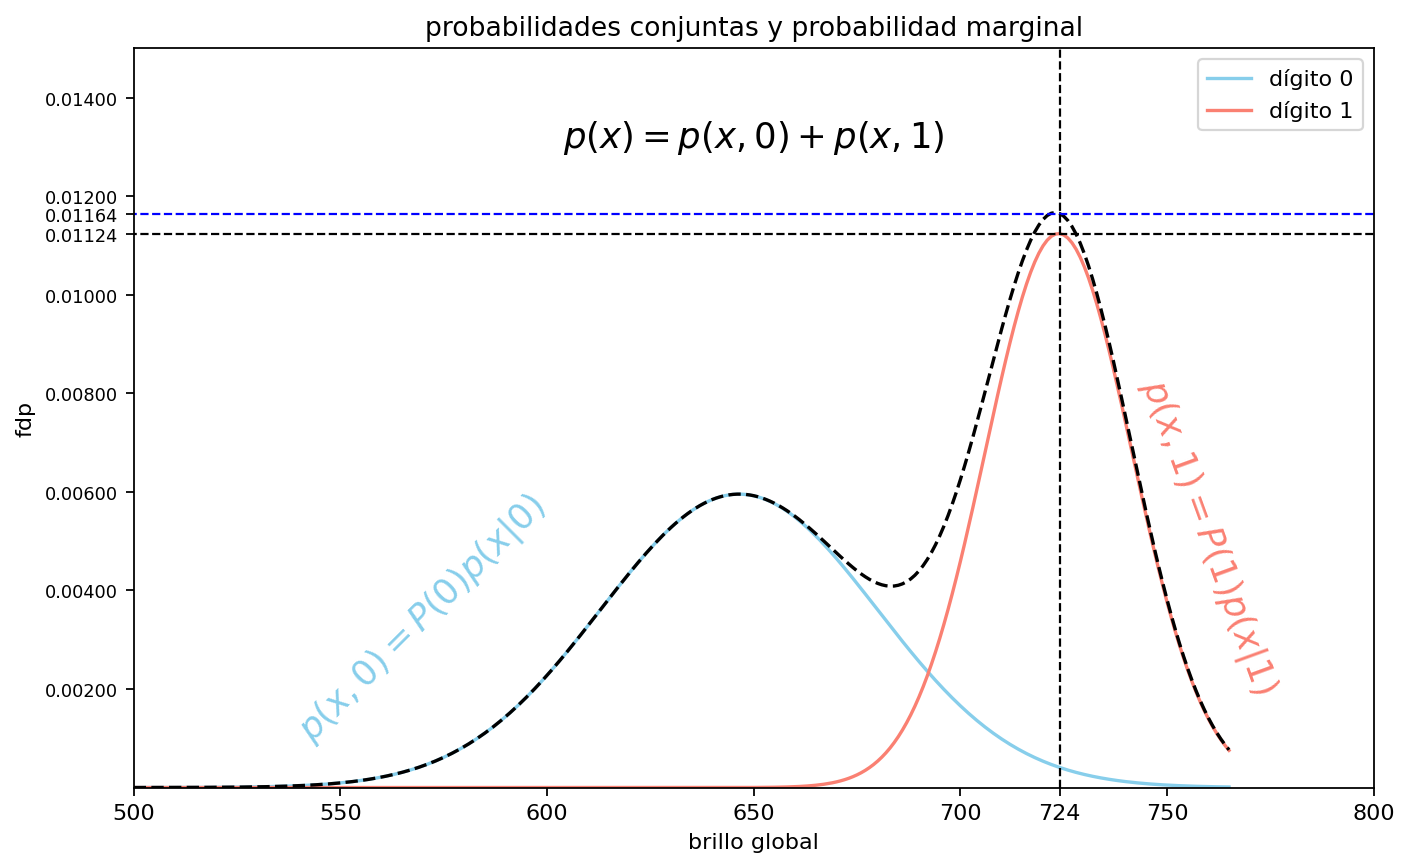

In [10]:
display(Image(filename=str(figure_dir + 'prob_conjunta_marginal.png'), width=1000))

Finalmente, utilizando la regla de Bayes se obtienen las probabilidades a posteriori:

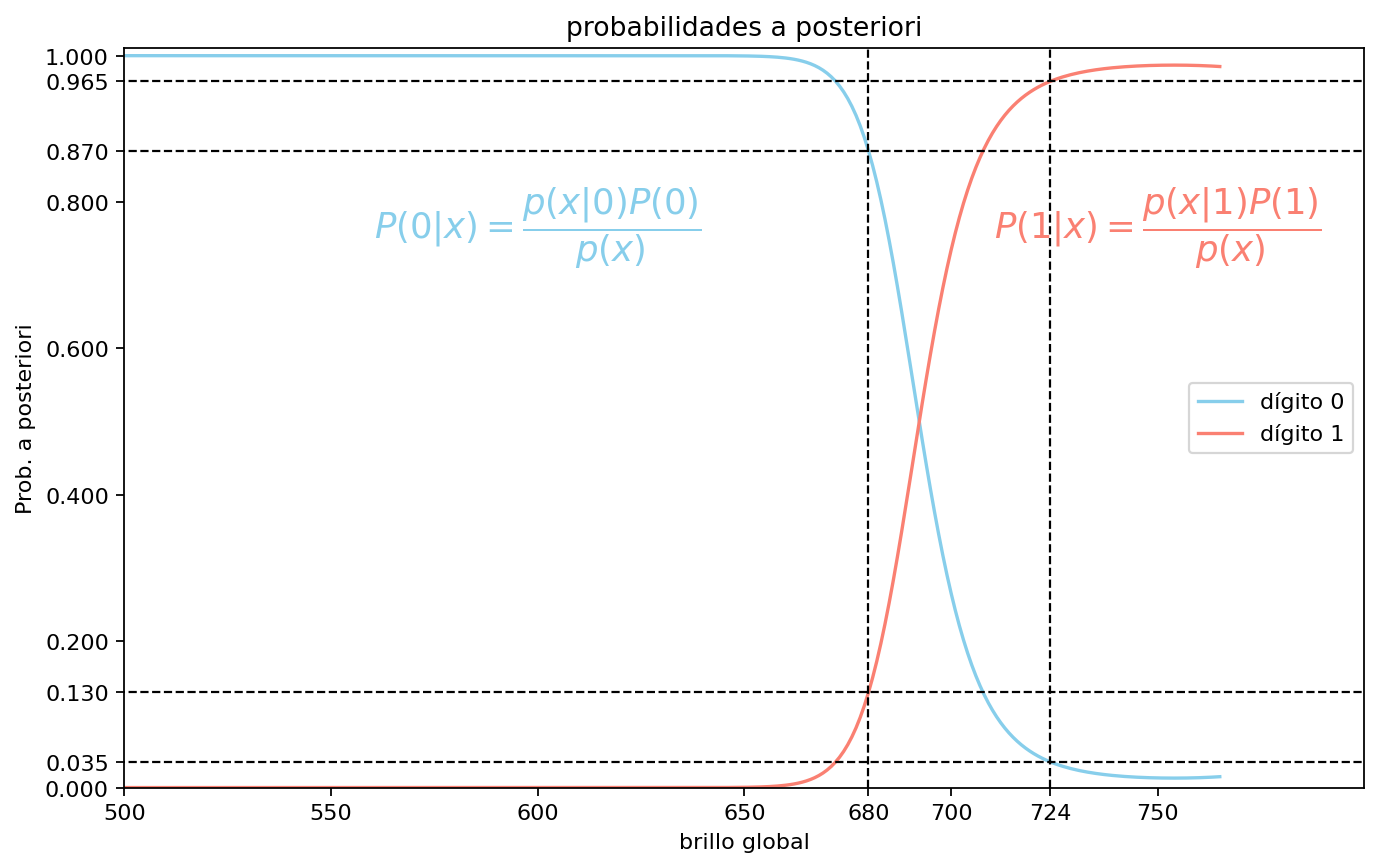

In [11]:
display(Image(filename=str(figure_dir + 'posteriori.png'), width=900))

## Implementación de la actividad práctica

Reproduzca el análisis anterior a partir del archivo `digitos_0_1.csv`. En cada etapa compare sus resultados con las figuras de referencia.

# **Funciones utilizadas en el trabajo:**

In [4]:
def brillo_global(imagen):
    return np.sum(imagen == 0)


def probabilidad_condicional(x, media, desvio):
    return stats.norm.pdf(x, loc=media, scale=desvio)


def densidad_conjunta(x, media, desvio, prob_prior):
    return probabilidad_condicional(x, media, desvio) * prob_prior


def densidad_marginal(p_w0, p_w1):
    return p_w0 + p_w1


def posterior(x, media_0, desvio_0, prior_0,
              media_1, desvio_1, prior_1):

    conjunta_0 = densidad_conjunta(
        x, media_0, desvio_0, prior_0
    )

    conjunta_1 = densidad_conjunta(
        x, media_1, desvio_1, prior_1
    )

    marginal = conjunta_0 + conjunta_1

    posterior_0 = conjunta_0 / marginal
    posterior_1 = conjunta_1 / marginal

    return posterior_0, posterior_1


def clasificar_bayes(x):
    p0 = densidad_conjunta(
        x, mu_0, sigma_0, P_w0
    )

    p1 = densidad_conjunta(
        x, mu_1, sigma_1, P_w1
    )

    if p0 > p1:
        return 0
    else:
        return 1


def cantidad_transiciones(imagen):
    imagen = imagen.reshape(28, 28)

    transiciones_horizontal = np.sum(
        imagen[:, 1:] != imagen[:, :-1]
    )

    transiciones_vertical = np.sum(
        imagen[1:, :] != imagen[:-1, :]
    )

    return transiciones_horizontal + transiciones_vertical

### 1. Carga y división de los datos

Cargue los datos y sepárelos en entrenamiento y prueba, utilizando un **20% para prueba**, `random_state=0` y `stratify` para preservar la proporción de clases. Separe predictores y etiquetas.

In [8]:
# Cargar los datos
df = pd.read_csv(data_dir + 'digitos_0_1.csv')

# Separar predictores y etiquetas
X = df.drop(columns=['target']).values
y = df['target'].values

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (4800, 784)
Datos de prueba: (1200, 784)


Se importan los datos, se separan los predictores de las etiquetas (target) y se dividen en conjuntos de entrenamiento (80%) y prueba (20%). El uso del parámetro stratify es fundamental para asegurar que la proporción original de dígitos '0' y '1' se mantenga idéntica en ambos conjuntos, permitiendo que el clasificador se entrene y se evalúe sin sesgos provocados por un desbalanceo de clases.

### 2. Procesamiento de datos

Binarice las intensidades utilizando el umbral 127:

- intensidad $>127 \rightarrow 1$;
- intensidad $\le 127 \rightarrow 0$.

Convierta luego los datos a arreglos de NumPy.

In [9]:
X_train_bin= (X_train > 127).astype(int)
X_test_bin= (X_test > 127).astype(int)

print(X_train_bin.shape)
print(X_test_bin.shape)

(4800, 784)
(1200, 784)


Para simplificar el análisis y la extracción de características, se transformó la escala de grises original a un formato binario utilizando un umbral de 127. Así el trazo principal del dígito (píxeles más claros) queda representado con el valor 1, mientras que el fondo de la imagen pasa a valer 0. La conversión a arreglos de NumPy deja los datos listos para operar matemáticamente.

### 3. Visualización de datos

Visualice los primeros 15 dígitos binarizados del conjunto de entrenamiento en una grilla de $3\times5$ y muestre la clase correspondiente a cada imagen. Compare con la Figura 1.

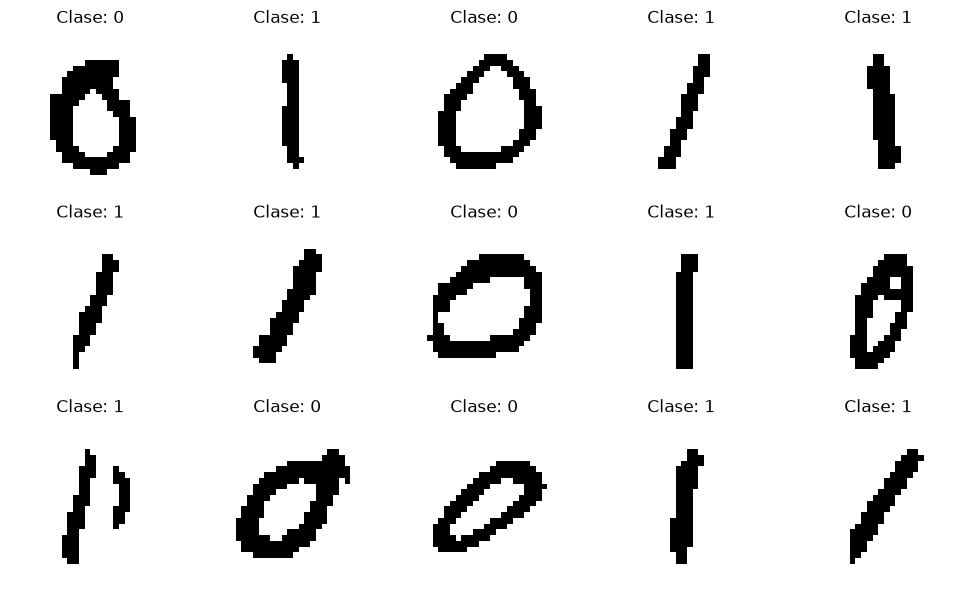

In [61]:
fig, axes=plt.subplots(3,5, figsize=(10,6))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_bin[i].reshape(28,28), cmap='gray_r')
    ax.set_title(f'Clase: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

Se graficaron los primeros 15 dígitos binarizados del conjunto de entrenamiento en una grilla de 3×5, con la clase correspondiente a cada imagen arriba. 

Comparando con la **Figura 1**, los dígitos y su orden coinciden exactamente, lo que confirma que la división con random_state=0 y el preprocesamiento reproducen los datos de referencia. 

Las imágenes se muestran con el trazo en negro sobre fondo blanco (`cmap='gray_r'`), igual que en la figura de referencia. En ellas se ve por qué la característica que sigue puede separar las clases: los 0 son trazos cerrados y anchos, y los 1 son trazos finos y casi verticales, con muchos menos píxeles de trazo.

### 4. Cálculo del brillo global

Implemente una función que reciba una imagen binarizada y devuelva la cantidad de píxeles iguales a 0. 

Aplique esta función a cada dígito del conjunto de datos para transformarlo a un conjunto de una única característica.

Aplique la función a entrenamiento y prueba.

Puede utilizar la función [np.apply_along_axis](https://numpy.org/doc/stable/reference/generated/numpy.apply_along_axis.html)

Grafique luego un histograma por clase y compárelo con la Figura 2.

In [14]:
brillo_train= np.apply_along_axis(brillo_global,1,X_train_bin)
brillo_test= np.apply_along_axis(brillo_global,1,X_test_bin)

print(brillo_train[:20])

[628 734 651 729 711 730 702 622 724 667 712 613 660 717 711 760 732 626
 706 736]


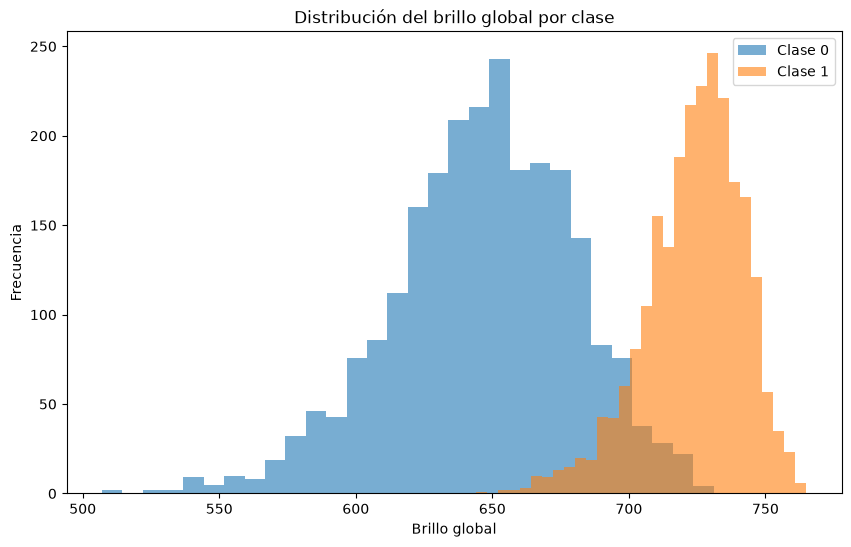

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    brillo_train[y_train == 0],
    bins=30,
    alpha=0.6,
    label='Clase 0'
)

plt.hist(
    brillo_train[y_train == 1],
    bins=30,
    alpha=0.6,
    label='Clase 1'
)

plt.xlabel('Brillo global')
plt.ylabel('Frecuencia')
plt.title('Distribución del brillo global por clase')
plt.legend()
plt.show()

Se implementó brillo_global, que cuenta los píxeles iguales a 0 de cada imagen (pixeles del fondo), y se aplicó con np.apply_along_axis a entrenamiento y prueba. Cada imagen de 784 valores quedó reducida a un único valor.

Al comparar el histograma con la **Figura 2**, la forma general es la misma. La clase 1 forma una distribución angosta y bastante simétrica con pico cerca de 725–730 y rango aproximado de 650 a 760. La clase 0 forma una distribución más ancha y asimétrica, centrada cerca de 650, con cola hacia valores bajos (hasta ~500) y varios picos irregulares. 

**Consideramos que esto es coherente debido a que:** como el brillo cuenta píxeles de fondo, el 0, que tiene más trazo, tiene menos píxeles en 0, mientras que el 1, que casi no ocupa la imagen, tiene más píxeles de fondo. 

Las dos clases se solapan en una zona de ~660–725, ahí se producirán los errores de clasificación. Las diferencias con la referencia son de escala y estilo. Nuestro gráfico usa solo los datos de entrenamiento (2400 por clase), con 30 bins y transparencia, mientras que la referencia usa más bins, lo que hace que las barras se vean más finas y el pico de la clase 1 (~250) coincida con el nuestro.

> Nota: el brillo global se calcula como la cantidad de píxeles de valor 0 (fondo). Visualizados como tinta negra sobre papel blanco, equivalen a los píxeles blancos de la imagen, por lo que un valor alto indica poco trazo.

### 5. Probabilidades a priori y parámetros por clase

Calcule $P(w_0)$ y $P(w_1)$ a partir del conjunto de entrenamiento. 

Calcule además la media y el desvío estándar del brillo global dentro de cada clase.

In [ ]:
P_w0 = np.mean(y_train ==0)
P_w1 = np.mean(y_train==1)

print("P(w0):", P_w0)
print("P(w1):", P_w1)

P(w0): 0.5
P(w1): 0.5


In [16]:
mu_0 = np.mean(brillo_train[y_train == 0])
sigma_0 = np.std(brillo_train[y_train == 0])

mu_1 = np.mean(brillo_train[y_train == 1])
sigma_1 = np.std(brillo_train[y_train == 1])

print("Clase 0:")
print("Media =", mu_0)
print("Desvío =", sigma_0)

print("\nClase 1:")
print("Media =", mu_1)
print("Desvío =", sigma_1)

Clase 0:
Media = 646.4433333333334
Desvío = 33.501979377675916

Clase 1:
Media = 723.7558333333334
Desvío = 17.744352603168018


Se estimaron las probabilidades a priori como la proporción de cada clase en entrenamiento: P(w₀) = P(w₁) = 0,5, lo esperable porque el dataset está balanceado y la partición fue estratificada.

**En cuanto a los parámetros del brillo global por clase:**

La clase 0 tiene menor brillo medio y más del doble de dispersión que la clase 1, lo que refleja la variabilidad de la forma del cero (tamaños y grosores distintos) frente a la regularidad del uno.

### 6. Modelado de las probabilidades condicionales con distribuciones gaussianas

Para cada clase $w_i$, modele el brillo global como

$$x\mid w_i\sim\mathcal N(\mu_i,\sigma_i^2).$$

Implemente una función para evaluar $p(x\mid w_i)$ utilizando [scipy.stats.norm.pdf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html). Recuerde que, para una variable continua, la función devuelve una **densidad** y no una probabilidad puntual.

Luego superponga ambas densidades gaussianas sobre los histogramas normalizados (`density=True`) y replique la Figura 3.

In [19]:
x_valores = np.linspace(
    min(brillo_train),
    max(brillo_train),
    1000
)

p_x_w0 = probabilidad_condicional(x_valores, mu_0, sigma_0)
p_x_w1 = probabilidad_condicional(x_valores, mu_1, sigma_1)

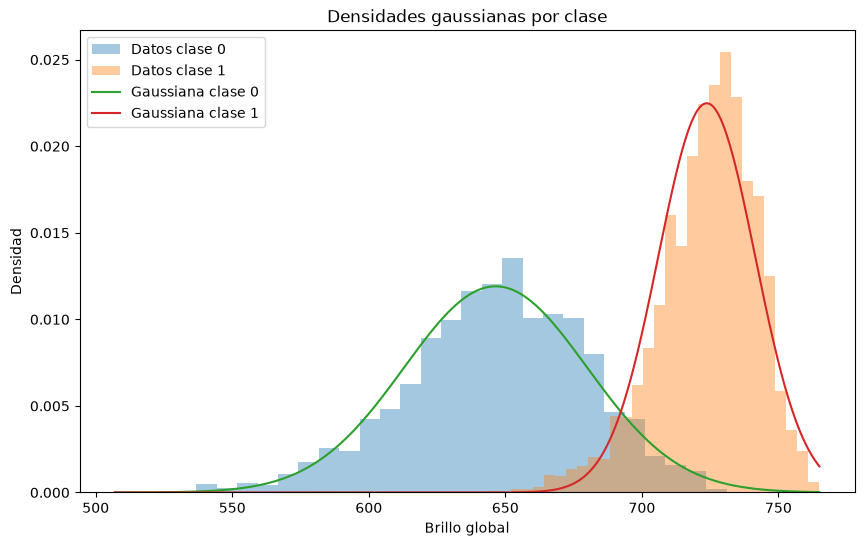

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    brillo_train[y_train == 0],
    bins=30,
    density=True,
    alpha=0.4,
    label='Datos clase 0'
)

plt.hist(
    brillo_train[y_train == 1],
    bins=30,
    density=True,
    alpha=0.4,
    label='Datos clase 1'
)

plt.plot(x_valores, p_x_w0, label='Gaussiana clase 0')
plt.plot(x_valores, p_x_w1, label='Gaussiana clase 1')

plt.xlabel('Brillo global')
plt.ylabel('Densidad')
plt.title('Densidades gaussianas por clase')
plt.legend()
plt.show()

Se modeló p(x | wᵢ) como una normal N(μᵢ, σᵢ²) usando scipy.stats.norm.pdf con los parámetros del punto anterior, y se superpuso sobre los histogramas normalizados (density=True), de modo que ambos estén en la misma escala de densidad.

Comparando con la **Figura 3**, el resultado es prácticamente idéntico. La gaussiana de la clase 1 es alta y angosta, con pico ≈ 0,0225, y la de la clase 0 es baja y ancha, con pico ≈ 0,015. En ambas el máximo cae en la media de su clase. **El ajuste es razonable pero no perfecto.** 

En la clase 1 el histograma tiene su moda un poco a la derecha de la campana y una cola izquierda algo más pesada. En la clase 0 el histograma es más irregular y asimétrico, con cola a la izquierda y picos locales (~675) que la gaussiana suaviza. Aun así, la campana captura bien la ubicación y el ancho de cada distribución, que es lo importante para clasificar. 

Las curvas se cruzan alrededor de x ≈ 690, que es la zona de solapamiento donde ambas clases son plausibles. 

**Que la campana no sea perfecta anticipa que el clasificador tendrá algunos errores y no llegará al 100 %.**

### 7. Cálculo de la densidad conjunta

Implemente

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

Grafique ambas densidades conjuntas y replique la Figura 4.

Verifique el valor para $x=724$ y la clase 1 y márquelo en el gráfico. 

In [21]:
p_x_w0_conjunta = densidad_conjunta(
    x_valores,
    mu_0,
    sigma_0,
    P_w0
)

p_x_w1_conjunta = densidad_conjunta(
    x_valores,
    mu_1,
    sigma_1,
    P_w1
)

In [22]:
x = 724

valor_724_clase1 = densidad_conjunta(
    x,
    mu_1,
    sigma_1,
    P_w1
)

print("p(x=724, w1) =", valor_724_clase1)

p(x=724, w1) = 0.011240323114904718


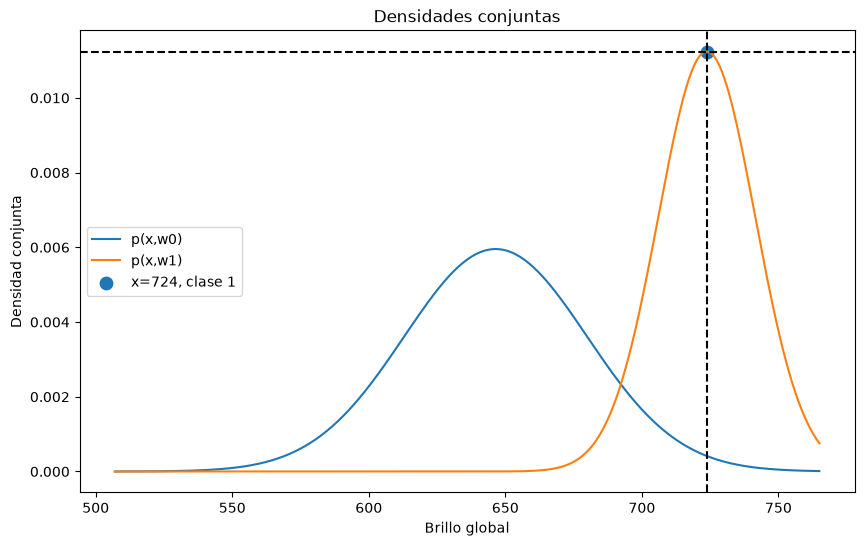

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_valores,
    p_x_w0_conjunta,
    label='p(x,w0)'
)

plt.plot(
    x_valores,
    p_x_w1_conjunta,
    label='p(x,w1)'
)

plt.scatter(
    724,
    valor_724_clase1,
    s=80,
    label='x=724, clase 1'
)

plt.axvline(724, ls='--', c='k')
plt.axhline(valor_724_clase1, ls='--', c='k')
plt.xlabel('Brillo global')
plt.ylabel('Densidad conjunta')
plt.title('Densidades conjuntas')
plt.legend()
plt.show()

Se implementó p(x, wᵢ) = p(x | wᵢ) P(wᵢ) y se evaluó sobre el rango de brillo para ambas clases. Para x = 724 y la clase 1 se obtuvo p(724, w₁) = 0,01124, que coincide con el valor marcado en la Figura 4.

**Al comparar con la Figura 4, las curvas son las mismas:** 

Como P(w₀) = P(w₁) = 0,5, cada conjunta es la gaussiana correspondiente multiplicada por 0,5, pero se mantiene la relación entre ellas: la de la clase 1 sigue siendo más alta y angosta. 

El punto x = 724 cae prácticamente en el máximo de p(x, w₁), lo cual es lógico porque 724 ≈ μ₁ = 723,76. En ese mismo x la conjunta de la clase 0 vale ≈0,0004, unas 27 veces menos que la de la clase 1, así que una muestra con brillo 724 es casi seguro un 1. 

Las dos curvas se cruzan en x ≈ 690: a la izquierda domina la clase 0 y a la derecha la clase 1, y ese cruce es el umbral de decisión del clasificador cuando los priors son iguales.

### 8. Cálculo de la densidad marginal

Implemente la suma sobre clases:

$$p(x)=\sum_i p(x\mid w_i)P(w_i).$$

Verifique el valor para $x=724$ y grafique la marginal junto con las densidades conjuntas, replicando la Figura 5.

In [24]:
p_x = densidad_marginal(
    p_x_w0_conjunta,
    p_x_w1_conjunta
)

In [25]:
p_724_w0 = densidad_conjunta(
    724,
    mu_0,
    sigma_0,
    P_w0
)

p_724_w1 = densidad_conjunta(
    724,
    mu_1,
    sigma_1,
    P_w1
)

p_724 = p_724_w0 + p_724_w1

print("p(x=724) =", p_724)

p(x=724) = 0.011648718807313038


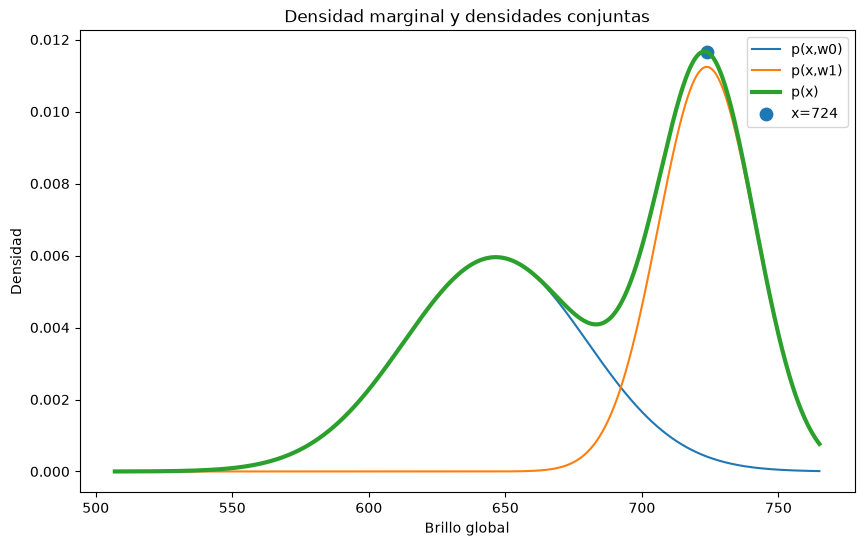

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(x_valores, p_x_w0_conjunta, label='p(x,w0)')
plt.plot(x_valores, p_x_w1_conjunta, label='p(x,w1)')
plt.plot(x_valores, p_x, label='p(x)', linewidth=3)

plt.scatter(724, p_724, s=80, label='x=724')

plt.xlabel('Brillo global')
plt.ylabel('Densidad')
plt.title('Densidad marginal y densidades conjuntas')
plt.legend()
plt.show()

Se implementó p(x) = p(x, w₀) + p(x, w₁), sumando las dos densidades conjuntas. Para x = 724 se obtuvo p(724) = 0,011649, que coincide con el valor de la Figura 5 (0,01164). Este valor es apenas mayor que p(724, w₁) = 0,01124 porque la clase 0 aporta una contribución pequeña (≈0,0004) en ese punto.

**Comparando con la Figura 5:** 

La curva verde de la marginal tiene la misma forma que la línea negra punteada de la referencia. **Es bimodal:** un primer máximo cerca de 650 (≈0,006), un valle cerca de 680 (≈0,004) y un segundo máximo, más alto, cerca de 725 (≈0,012). En los extremos la marginal coincide con la conjunta que domina en cada zona. A la izquierda, donde solo hay ceros, se superpone con p(x, w₀). A la derecha, donde solo hay unos, se superpone con p(x, w₁). Se separa de ambas únicamente en la zona intermedia (~660–730), donde las dos clases aportan a la vez. Ese es el sentido de la marginal: describe qué tan frecuente es observar un brillo x sin importar la clase, y su valle marca la zona donde las clases se mezclan y hay ambigüedad. Las diferencias con la referencia son solo de presentación (líneas punteadas, ecuaciones sobre las curvas), no de resultado.

### 9. Cálculo de las probabilidades a posteriori

Implemente la regla de Bayes para calcular $P(w_i\mid x)$ para todas las clases.

Verifique los resultados para $x=680$ y $x=724$ y replique la Figura 6.

In [27]:
for x in [680, 724]:

    p0, p1 = posterior(
        x,
        mu_0, sigma_0, P_w0,
        mu_1, sigma_1, P_w1
    )

    print(f"x = {x}")
    print("P(w0 | x) =", p0)
    print("P(w1 | x) =", p1)
    print()

x = 680
P(w0 | x) = 0.8702493503733311
P(w1 | x) = 0.12975064962666882

x = 724
P(w0 | x) = 0.03505927983701783
P(w1 | x) = 0.9649407201629822



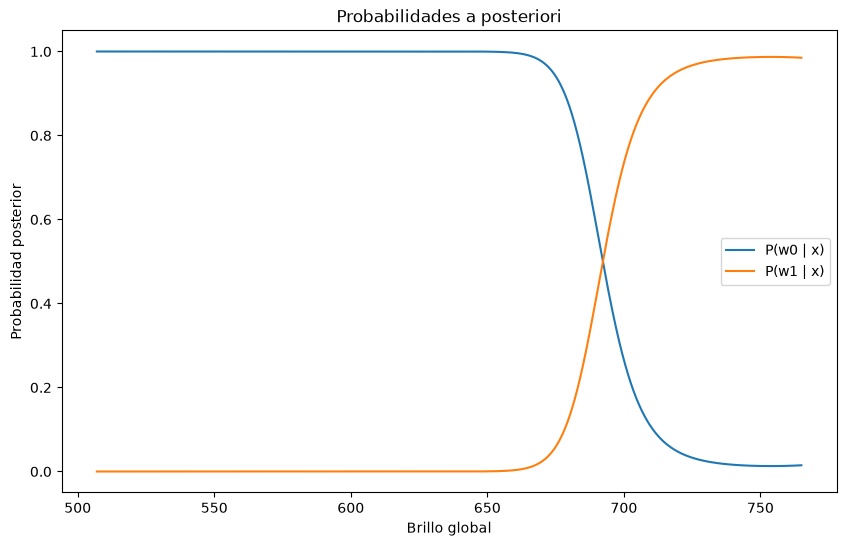

In [28]:
posterior_0 = []
posterior_1 = []

for x in x_valores:

    p0, p1 = posterior(
        x,
        mu_0, sigma_0, P_w0,
        mu_1, sigma_1, P_w1
    )

    posterior_0.append(p0)
    posterior_1.append(p1)

plt.figure(figsize=(10, 6))

plt.plot(x_valores, posterior_0, label='P(w0 | x)')
plt.plot(x_valores, posterior_1, label='P(w1 | x)')

plt.xlabel('Brillo global')
plt.ylabel('Probabilidad posterior')
plt.title('Probabilidades a posteriori')
plt.legend()
plt.show()

Se implementó la regla de Bayes, P(wᵢ | x) = p(x, wᵢ) / p(x), y se evaluó en dos puntos:

| $x$ | $P(w_0\mid x)$ | $P(w_1\mid x)$ |
|:---:|:---:|:---:|
| 680 | 0,870 | 0,130 |
| 724 | 0,035 | 0,965 |

Ambos pares suman 1, como corresponde, y coinciden con los valores marcados en la Figura 6 (0,870 / 0,130 y 0,035 / 0,965).

**Comparando con la Figura 6:** 

**Las curvas son equivalentes.** Para brillos bajos P(w₀ | x) ≈ 1, así que la imagen es casi con certeza un 0. Para brillos altos, P(w₁ | x) se acerca a 1 y la imagen es casi con certeza un 1. Entre ~660 y ~730 hay una transición en forma de S, que es la zona de solapamiento vista en los histogramas. Las curvas se cruzan en P = 0,5 alrededor de x ≈ 690, el mismo punto donde se cruzaban las conjuntas. **Ese es el umbral de decisión:** a la izquierda se clasifica como 0 y a la derecha como 1. 

Los dos puntos elegidos ilustran distintos niveles de confianza. En x = 724 el modelo es muy seguro (96,5 % de clase 1), mientras que en x = 680 ya está más cerca del límite y su confianza en la clase 0 baja al 87 %. 

Un detalle es que hacia el extremo derecho P(w₀ | x) sube levemente en lugar de seguir cayendo a 0 (se ve en ambos gráficos). Ocurre porque la gaussiana de la clase 0 es más ancha y su cola decae más lento que la de la clase 1, y es una consecuencia de usar varianzas distintas por clase.

### 10. Regla MAP y clasificación

Para clasificar no es necesario calcular explícitamente $p(x)$, porque el denominador es el mismo para todas las clases. Compruebe que

$$\arg\max_i P(w_i\mid x)=\arg\max_i p(x\mid w_i)P(w_i).$$

Obtenga las predicciones sobre el conjunto de prueba y calcule la exactitud (*accuracy*).

In [29]:
y_pred = np.array([
    clasificar_bayes(x)
    for x in brillo_test
])

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


Como p(x) es el mismo para las dos clases, comparar P(w₀ | x) con P(w₁ | x) es equivalente a comparar p(x | w₀)P(w₀) con p(x | w₁)P(w₁). Por eso clasificar_bayes compara solo las densidades conjuntas, sin calcular la marginal, y asigna la clase con mayor valor. Aplicada al conjunto de prueba, la exactitud fue de 0,9333 (93,3 %), es decir que se clasificaron bien 1120 de las 1200 imágenes. Los errores se concentran en la zona de solapamiento entre ~660 y ~730, donde una sola característica no alcanza para distinguir bien los dos dígitos.

# 4. Comparación con Scikit-Learn

Entrene [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB) utilizando solamente el brillo global. Compare las predicciones y el desempeño con la implementación manual.

Luego inspeccione `class_prior_`, `theta_` y `var_` del objeto entrenado e interprete qué cantidad del desarrollo anterior representa cada atributo.

In [30]:
modelo_nb = GaussianNB()

modelo_nb.fit(
    brillo_train.reshape(-1, 1),
    y_train
)

y_pred_nb = modelo_nb.predict(
    brillo_test.reshape(-1, 1)
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("Accuracy implementación manual:", accuracy)
print("Accuracy GaussianNB:", accuracy_nb)

Accuracy implementación manual: 0.9333333333333333
Accuracy GaussianNB: 0.9333333333333333


In [60]:
print("class_prior_:")
print(modelo_nb.class_prior_)

print("\ntheta_:")
print(modelo_nb.theta_)

print("\nvar_:")
print(modelo_nb.var_)

print("\n Son iguales las predicciones? \n", np.array_equal(y_pred, y_pred_nb))

class_prior_:
[0.5 0.5]

theta_:
[[646.44333333]
 [723.75583333]]

var_:
[[1122.38262444]
 [ 314.86205152]]

 Son iguales las predicciones? 
 True


Se entrenó GaussianNB con el brillo global como única característica y se evaluó sobre el mismo conjunto de prueba. 

La exactitud fue 0,9333, exactamente igual a la de la implementación manual, lo que indica que ambos modelos toman las mismas decisiones. Esto es esperable, porque GaussianNB hace lo mismo que se programó a mano: ajusta una gaussiana por clase y aplica la regla MAP.

| Atributo | Valor | Cantidad del desarrollo manual |
|:---|:---|:---|
| `class_prior_` | 0,5 y 0,5 | Probabilidades a priori $P(w_0)$ y $P(w_1)$ |
| `theta_` | 646,44 y 723,76 | Medias $\mu_0$ y $\mu_1$ del brillo por clase |
| `var_` | 1122,38 y 314,86 | Varianzas $\sigma_0^2$ y $\sigma_1^2$ por clase |

* **Los valores de theta_ coinciden con las medias del punto 5.** 

* Los de var_ son las varianzas, no los desvíos: 1122,38 = 33,50² y 314,86 = 17,74². **Coinciden con nuestros σ** porque np.std usa por defecto la varianza poblacional, que es la que usa scikit-learn. 

En resumen, con una sola característica GaussianNB reproduce el clasificador de Bayes construido paso a paso, solo lo automatiza.

# 5. Del clasificador de Bayes al clasificador Naive Bayes

Hasta ahora se utilizó una única característica:

$$x=\text{brillo global}.$$

Por eso no fue necesario realizar ningún supuesto sobre relaciones entre características. Al representar una muestra mediante varias características,

$$\mathbf{x}=(x_1,x_2,\ldots,x_d),$$

sería necesario estimar la densidad conjunta

$$p(x_1,x_2,\ldots,x_d\mid w_i).$$

Naive Bayes simplifica este problema suponiendo **independencia condicional dada la clase**:

$$p(x_1,x_2,\ldots,x_d\mid w_i)=\prod_{j=1}^{d}p(x_j\mid w_i).$$

Trabajaremos ahora con dos características extraídas de cada imagen:

1. brillo global;
2. cantidad de transiciones entre píxeles vecinos horizontales y verticales, utilizada como una medida sencilla de bordes/complejidad de la forma.

### 1. Cargar y dividir los datos

Vuelva a cargar el CSV, separe predictores y etiquetas y realice una partición 80/20 con `random_state=0` y `stratify=y`.

In [33]:
df = pd.read_csv(data_dir + 'digitos_0_1.csv')

X = df.drop(columns=['target']).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

X_train_bin = (X_train > 127).astype(int)
X_test_bin = (X_test > 127).astype(int)

Se volvieron a cargar los datos de digitos_0_1.csv, se separaron predictores y etiquetas y se repitió la partición 80/20 con random_state=0 y stratify=y. 

Al usar los mismos parámetros que antes se obtienen exactamente los mismos conjuntos de entrenamiento y prueba, lo que permite comparar el modelo de una característica con el de dos características sobre las mismas muestras. También se repitió la binarización con umbral 127.

### 2. Binarizar y calcular las dos características

Binarice las imágenes usando el mismo umbral. 

Implemente las funciones necesarias para obtener el brillo global y la cantidad de transiciones entre píxeles vecinos. 

Construya matrices de características de dos columnas para entrenamiento y prueba.

In [34]:
brillo_train = np.apply_along_axis(
    brillo_global,
    1,
    X_train_bin
)

brillo_test = np.apply_along_axis(
    brillo_global,
    1,
    X_test_bin
)

transiciones_train = np.apply_along_axis(
    cantidad_transiciones,
    1,
    X_train_bin
)

transiciones_test = np.apply_along_axis(
    cantidad_transiciones,
    1,
    X_test_bin
)

In [38]:
X_train_2 = np.column_stack(
    (brillo_train, transiciones_train)
)

X_test_2 = np.column_stack(
    (brillo_test, transiciones_test)
)

print(X_train_2[:10])
print("\n")
print(X_test_2[:10])

[[628 112]
 [734  50]
 [651 130]
 [729  58]
 [711  52]
 [730  56]
 [702  64]
 [622 130]
 [724  48]
 [667 102]]


[[720  56]
 [727  54]
 [710  66]
 [613 128]
 [746  44]
 [733  64]
 [738  50]
 [656 126]
 [740  64]
 [589 132]]


Además del brillo global, se implementó cantidad_transiciones, que reordena cada imagen como una matriz de 28×28 y cuenta las veces que el valor de un píxel cambia respecto de su vecino, tanto en horizontal como en vertical. Es una medida sencilla de la cantidad de bordes de la forma. Con ambas características se armaron matrices de dos columnas para entrenamiento (4800×2) y prueba (1200×2).

En las primeras filas se ve por qué la segunda característica ayuda. Los ceros (por ejemplo [628, 112], [651, 130], ...) tienen muchas transiciones, porque su trazo curvo y cerrado cruza muchas veces el borde entre trazo y fondo. Los unos (por ejemplo [734, 50], [729, 58], ...) tienen pocas transiciones, porque son un trazo fino y casi recto. 

En la zona donde el brillo global solo se solapaba (≈660–730), las transiciones separan claramente las clases (≈100 para los ceros contra ≈65 para los unos). Por eso se espera que el modelo con dos características rinda mejor que el anterior.

### 3. Entrenamiento y evaluación

Entrene `GaussianNB` con las dos características. Obtenga las predicciones, la exactitud, la matriz de confusión y el `classification_report`. Investigue que devuelve `classification_report`

In [39]:
modelo_nb_2 = GaussianNB()

modelo_nb_2.fit(
    X_train_2,
    y_train
)

y_pred_2 = modelo_nb_2.predict(X_test_2)

accuracy_2 = accuracy_score(
    y_test,
    y_pred_2
)

print("Accuracy:", accuracy_2)

Accuracy: 0.9966666666666667


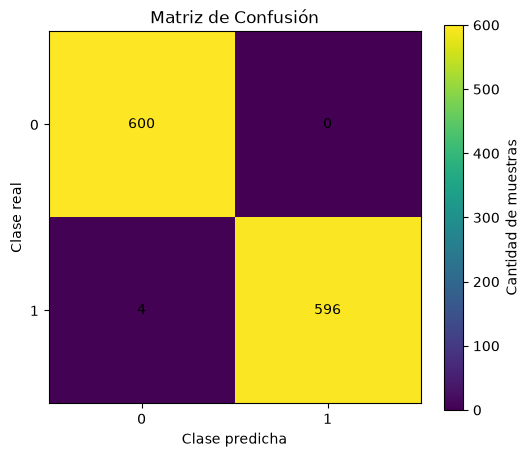

In [42]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_2)

# Graficarla
plt.figure(figsize=(6, 5))

plt.imshow(cm)

# Título y nombres de los ejes
plt.title("Matriz de Confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

# Marcas de los ejes
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])

# Mostrar los valores dentro de cada cuadrado
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Cantidad de muestras")
plt.show()

In [41]:
print(
    classification_report(
        y_test,
        y_pred_2
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       600
           1       1.00      0.99      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



Se entrenó GaussianNB con las dos características (brillo global y cantidad de transiciones) y se evaluó sobre el conjunto de prueba. La exactitud fue de 0,9967, es decir que se clasificaron bien 1196 de las 1200 imágenes. Con solo el brillo global se había obtenido 0,9333, agregar la segunda característica redujo los errores de 80 a 4.

Los 600 ceros se clasificaron correctamente, y los errores detectados son unos clasificados como ceros.

classification_report: da la **precision** (de las imágenes que el modelo predijo como esa clase, qué proporción realmente lo eran), el **recall** (de las imágenes que realmente eran de esa clase, qué proporción detectó el modelo), el **f1-score** (media armónica entre precision y recall) y el **support** (cantidad de muestras reales de esa clase en el conjunto de prueba). **Support** nos muestra la cantidad de muestras de cada clase, siendo 600 y 600, el conjunto de datos está balanceado.

* Clase 0: tiene recall 1,00 porque no se perdió ningún cero, pero su precision baja a 0,99 (600 de 604) porque 4 unos fueron etiquetados como ceros. 
* Clase 1: tiene precision 1,00 porque todo lo que se predijo como 1 era un 1, pero su recall es 0,99 (596 de 600) por esos mismos 4 unos que se perdieron. 


### 4. Visualización de la clasificación

Realice un diagrama de dispersión sobre el conjunto de prueba:

- eje X: brillo global;
- eje Y: cantidad de transiciones/bordes;
- color: clase predicha.

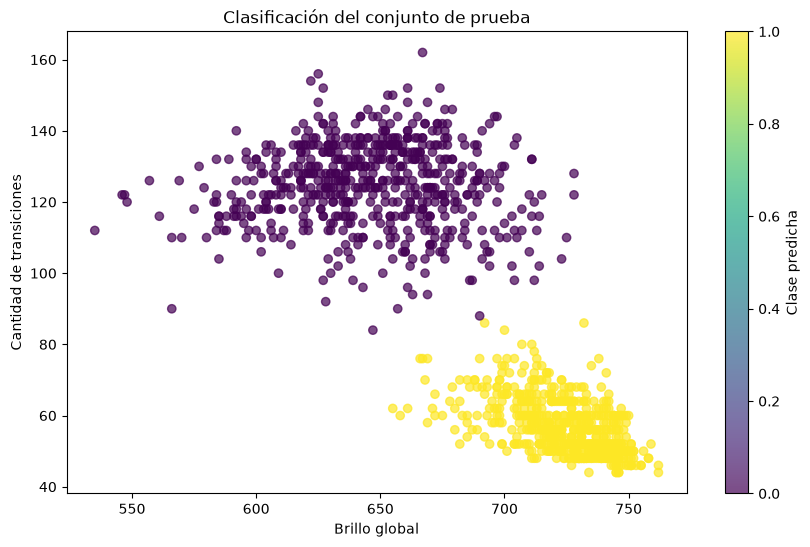

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test_2[:, 0],
    X_test_2[:, 1],
    c=y_pred_2,
    alpha=0.7
)

plt.xlabel('Brillo global')
plt.ylabel('Cantidad de transiciones')
plt.title('Clasificación del conjunto de prueba')
plt.colorbar(label='Clase predicha')

plt.show()

Se graficó el conjunto de prueba con el brillo global en el eje X, la cantidad de transiciones en el eje Y y el color según la clase predicha. El gráfico muestra dos nubes bien diferenciadas:

- **Clase 0 (violeta):** con aprox. entre 90 y 160 transiciones y un brillo global muy disperso (aprox. 530 a 730). Los ceros tienen un contorno curvo y cerrado que produce muchos cambios entre trazo y fondo.
- **Clase 1 (amarillo):** con aprox. entre 40 y 90 transiciones y brillo global alto (aprox. 660 a 760). Los unos son trazos finos y casi rectos, con pocos bordes y mucho fondo.

La ventaja de la segunda característica se ve al comparar con el histograma del punto 4 de la primera parte, donde las clases se superponían entre ~660 y ~730 de brillo, mientras que en esta representación, con esta caracteristica, esa superposición desaparece, porque las dos nubes están separadas verticalmente; entre ambas hay una franja con muy pocas instancias alrededor de 90 transiciones. 

Una característica que por sí sola no distinguía bien las clases resulta útil cuando se combina con otra que aporta información distinta.

### 5. Fronteras de decisión

Grafique las regiones de decisión del clasificador sobre el plano de las dos características. Utilice la función provista a continuación y superponga los datos de prueba coloreados según su **clase real**.

In [45]:
def plot_decision_regions(model, X, y, x_label='Feature 1', y_label='Feature 2', title='Decision regions'):
    """Plot 2D decision regions and true class labels."""
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

    x_values = np.linspace(x_min, x_max, 300)
    y_values = np.linspace(y_min, y_max, 300)
    xx, yy = np.meshgrid(x_values, y_values)

    grid = np.column_stack((xx.ravel(), yy.ravel()))
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, zz, alpha=0.35, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', cmap=plt.cm.coolwarm)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.colorbar(scatter, label='Clase real')
    plt.show()

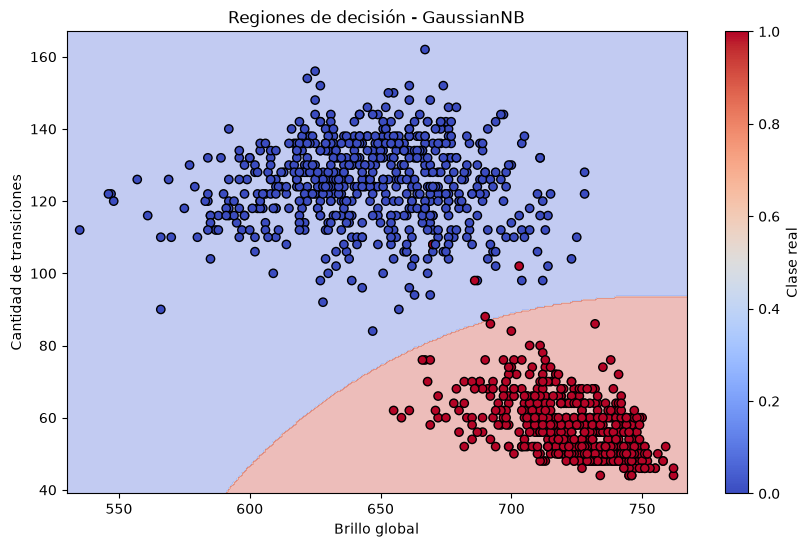

In [46]:
plot_decision_regions(
    modelo_nb_2,
    X_test_2,
    y_test,
    x_label='Brillo global',
    y_label='Cantidad de transiciones',
    title='Regiones de decisión - GaussianNB'
)

Se graficaron las regiones de decisión de GaussianNB sobre el plano de las dos características, con los puntos de prueba coloreados según su clase (rojo -> 1; azul -> 0)

**La frontera es curva, no recta:** que sea curva es coherente con el modelo. GaussianNB estima una varianza distinta para cada clase, y cuando las varianzas son diferentes la frontera de decisión resulta cuadrática. Solo sería una recta si ambas clases tuvieran la misma varianza. La frontera pasa por la franja vacía entre las dos nubes, y por eso separa tan bien los datos.

Los puntos de la clase 0 quedan todos dentro de su región. Los únicos errores son unos reales que caen dentro de la región azul, cerca del borde y con 100 transiciones, es decir, con más bordes de lo habitual. Son los 4 errores de la matriz de confusión. 

### 6. ¿Qué tan razonable es el supuesto *Naive*?

Analice la relación entre las dos características **dentro de cada clase**. Como diagnóstico sencillo, calcule el coeficiente de correlación lineal por clase.

> Importante: correlación nula **no demuestra independencia**. Sin embargo, una correlación claramente distinta de cero sí evidencia dependencia lineal.

En este ejemplo, ¿las dos características parecen cumplir exactamente la independencia condicional?

In [47]:
corr_0 = np.corrcoef(
    brillo_train[y_train == 0],
    transiciones_train[y_train == 0]
)[0, 1]

corr_1 = np.corrcoef(
    brillo_train[y_train == 1],
    transiciones_train[y_train == 1]
)[0, 1]

print("Correlación clase 0:", corr_0)
print("Correlación clase 1:", corr_1)

Correlación clase 0: 0.015489733152243966
Correlación clase 1: -0.5403456953627335


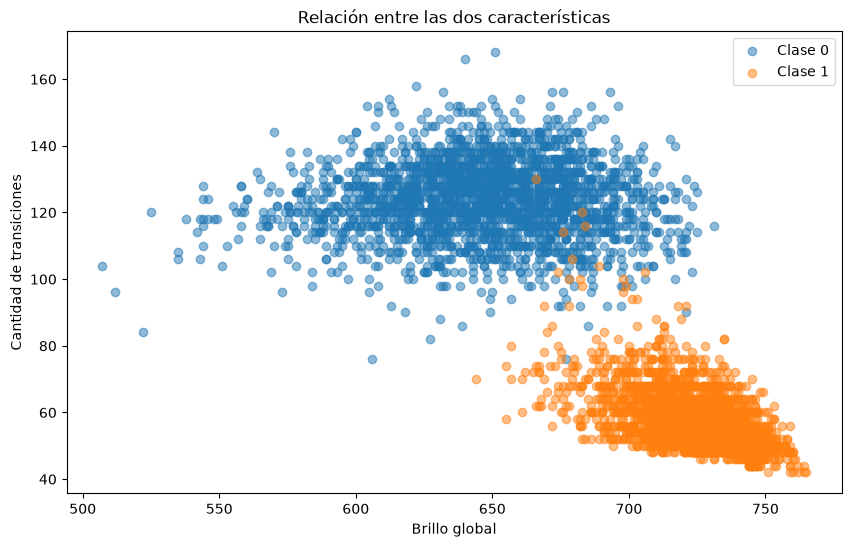

In [48]:
plt.figure(figsize=(10, 6))

plt.scatter(
    brillo_train[y_train == 0],
    transiciones_train[y_train == 0],
    alpha=0.5,
    label='Clase 0'
)

plt.scatter(
    brillo_train[y_train == 1],
    transiciones_train[y_train == 1],
    alpha=0.5,
    label='Clase 1'
)

plt.xlabel('Brillo global')
plt.ylabel('Cantidad de transiciones')
plt.title('Relación entre las dos características')
plt.legend()

plt.show()

Se calculó el coeficiente de correlación lineal entre el brillo global y la cantidad de transiciones dentro de cada clase:

| Clase | Correlación |
|:---:|:---:|
| 0 | 0,015 |
| 1 | −0,540 |

En la clase 0 la correlación es casi nula. Coincide con el diagrama de dispersión, donde la nube de ceros es una mancha ancha sin inclinación clara, de modo que en esa clase las dos características parecen prácticamente incorrelacionadas.

En la clase 1 la correlación es negativa (−0,54): a mayor brillo global, menos transiciones. Tiene sentido, porque ambas características dependen de la cantidad de trazo del dígito. Como el brillo global se calculó contando los píxeles de fondo, un brillo mayor significa menos trazo, por lo que tiene menos bordes, es decir, menos transiciones.

Las dos características no cumplen totalmente la independencia condicional que supone Naive Bayes. Para la clase 0 el supuesto es posible, aunque una correlación lineal nula no demuestra por sí sola que haya independencia. En la clase 1 hay una dependencia lineal evidente.

Sin embargo, el clasificador funciona muy bien (exactitud de 0,9967). Esto se debe a que Naive Bayes solo necesita que las probabilidades a posteriori ordenen correctamente las clases, no que estén perfectamente calibradas. Como las nubes están bien separadas, incluso un modelo que ignora la correlación de la clase 1 toma casi siempre la decisión correcta. Que el supuesto sea aproximado afecta poco a la clasificación, aunque las probabilidades que devuelve el modelo pueden ser menos confiables que las de un modelo que sí modele esa dependencia.